# GitHub Activity as an Alt-Data Nowcast — a quantitative teardown 🔬
### Per-period Spearman IC · label-shuffle placebo · decile long-short + borrow · tail/sub-sample robustness · seed-robust synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We treat public GitHub velocity as a cross-sectional predictor and run the standard nowcast teardown: the information coefficient, its *t*, a placebo null, a long-short book, robustness, and a planted-effect control.

> ⚠️ **Not investment advice — and synthetic-only.** No free, point-in-time, survivorship-clean GitHub→ticker tape exists (renames, archives, private moves, rate limits), so *every* cell here is a deterministic simulated world (seed 553, panel fp `33d0732cb08f`) with the believers' effect planted at a **realistic** `ic = 0.03`. A synthetic-only study can never earn `REAL` — the ceiling is `WEAK`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from github_activity import data, strategy as st

# Synthetic-only: the point-in-time GitHub->ticker tape does not exist on a free stack, so the
# whole study runs on this deterministic panel. ic = 0.03 plants a *realistic* alt-data effect.
IC_PLANT = 0.03
PANEL, TRUTH = data.synthetic_panel(ic=IC_PLANT, seed=553)
print("synthetic panel:", PANEL.shape[0], "rows |",
      PANEL.firm.nunique(), "firms x", PANEL.period.nunique(), "quarters |",
      "planted ic =", IC_PLANT, "| fp", data.fingerprint(PANEL))


synthetic panel: 1200 rows | 30 firms x 40 quarters | planted ic = 0.03 | fp 33d0732cb08f


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Mean per-period Spearman IC **+0.045** at *t* **1.64** (right sign, below the ≥ 2 bar), placebo *p* **0.122**; significance flickers across cuts; **no real tape possible** ⇒ capped at `WEAK`. |
| **Tradability** | `MIRAGE` | The point-in-time signal is un-reconstructable on a free stack; on top, the long-short shorts the laggards (borrow). Gross **+14.1%/yr** (*t* 1.51) → net **+12.3%/yr**, never clearing significance. |

> 💡 In plain words: the engine works (the synthetic control proves it), the planted effect is recovered with the right sign — but at a realistic alt-data strength it doesn't clear *t* = 2, and the real data needed to certify it doesn't exist.

## 1 · The claim, steelmanned

Let $v_{i,t}$ be firm $i$'s cross-sectionally z-scored GitHub velocity at rebalance $t$ and $r_{i,t+1}$ its forward return.

- **H₁ (nowcast).** The per-period rank IC $\rho_t = \text{corr}(\text{rank } v_{\cdot,t}, \text{rank } r_{\cdot,t+1})$ has $\overline{\rho} > 0$ at *t* ≥ 2.
- **H₂ (tradable).** A long-top / short-bottom velocity book earns a positive spread at *t* ≥ 2, net of costs and the short-leg borrow.
- **H₃ (robust).** The IC's sign/strength is stable across tail fractions and sub-samples.
- **H₄ (data).** The signal can be reconstructed **point-in-time** on a free stack.

We find **H₁ not cleared** (right sign, *t* 1.64), **H₂ not cleared** (spread *t* 1.51), **H₃ fragile** (sign stable, significance flickers), and **H₄ false** (no point-in-time GitHub→ticker tape) — which alone caps the Signal at `WEAK`.

## 2 · So what? — what rides on each answer

The economic prior is real: innovation intensity has predicted returns (Chan-Lakonishok-Sougiannis 2001; Hirshleifer-Hsu-Li 2013), and GitHub velocity is a *live, output-side* proxy for it. Two forces cap it here: (a) a **realistic alt-data IC is small** (~0.03–0.05), so certifying it needs a long, clean tape; and (b) that tape **cannot be built** — GitHub feeds are current snapshots, so past velocity is survivorship-/look-ahead-contaminated. This is the same point-in-time wall as [392 Glassdoor](../../392-glassdoor-sentiment/) and [528 Hiring](../../528-labor-hiring-rate/).

## 3 · How we'd know — the protocol

- **Signal.** Cross-sectional z-scored velocity $v_{i,t}$ each quarter.
- **IC.** Per-period Spearman $\rho_t$ of velocity vs *forward* return; headline = $\overline{\rho}$ and its *t* = $\overline{\rho} / (s_\rho / \sqrt{T})$.
- **Placebo.** Shuffle velocity vs returns *within each period* (preserves the cross-sectional structure, breaks the link); *p* = tail fraction of |mean IC|.
- **Book.** Long top-$f$ / short bottom-$f$, equal weight, rebalanced each period; *t* on the spread.
- **Frictions.** One-way cost per leg per rebalance + annual borrow on the short leg.
- **Robustness.** $f \in \{0.1, 0.2, 1/3\}$ × {full, first half, second half}.
- **Positive control.** Plant $ic$ of increasing strength; average the IC-*t* over 25 seeds (house rule) — must be flat at the null and clear the bar as $ic$ grows.

Timing: velocity is a trailing z-score known at the rebalance close, scored against the *forward* return — one documented execution lag, no look-ahead.

## 4 · The teardown

### 4a · The information coefficient — H₁

Per-period Spearman IC of velocity vs forward return, with the mean and its *t*.

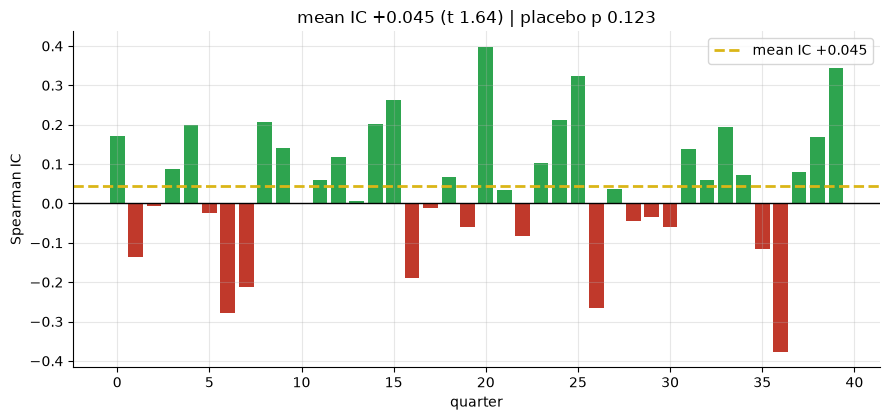

mean IC +0.045 | t 1.64 | positive 60% of quarters | placebo p 0.123


In [2]:
ics = st.period_ics(PANEL); summ = st.ic_summary(PANEL)
p = st.placebo_pvalue(PANEL, n_perm=1500, seed=553)
fig, ax = plt.subplots(figsize=(9, 4.3))
cols = [GREEN if v > 0 else RED for v in ics.values]
ax.bar(range(len(ics)), ics.values, color=cols, width=.8)
ax.axhline(0, c='k', lw=1)
ax.axhline(summ['mean_ic'], c=AMBER, lw=2, ls='--', label=f"mean IC {summ['mean_ic']:+.3f}")
ax.set_xlabel('quarter'); ax.set_ylabel('Spearman IC')
ax.set_title(f"mean IC {summ['mean_ic']:+.3f} (t {summ['t']:.2f}) | placebo p {p:.3f}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"mean IC {summ['mean_ic']:+.3f} | t {summ['t']:.2f} | "
      f"positive {summ['hit']*100:.0f}% of quarters | placebo p {p:.3f}")

> 💡 In plain words: H₁ **not cleared.** The IC is the right sign (+0.045) but *t* = 1.64 < 2 and the placebo *p* = 0.122 can't rule out luck. A genuine-but-tiny alt-data signal.

### 4b · The long-short book — H₂ (with costs + borrow)

Long top-quintile / short bottom-quintile velocity, then net of costs and the short-leg borrow.

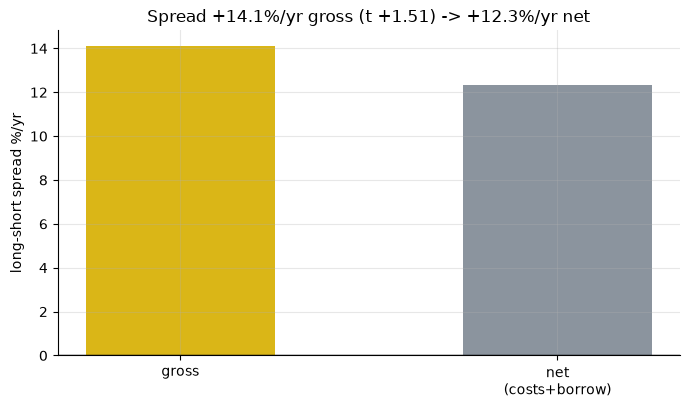

gross +14.1%/yr (t +1.51) -> net +12.3%/yr (10 bps/leg/qtr + 100 bps/yr borrow)


In [3]:
bk = st.long_short_book(PANEL, frac=0.2)
net = st.net_spread(bk, cost_bps=10.0, borrow_ann_bps=100.0)
gross, netv, t = net['gross_ann']*100, net['net_ann']*100, bk['t']
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross', 'net\n(costs+borrow)'], [gross, netv], color=[AMBER, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('long-short spread %/yr')
ax.set_title(f'Spread {gross:+.1f}%/yr gross (t {t:+.2f}) -> {netv:+.1f}%/yr net')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.1f}%/yr (t {t:+.2f}) -> net {netv:+.1f}%/yr '
      f'(10 bps/leg/qtr + 100 bps/yr borrow)')

> 💡 In plain words: H₂ **not cleared.** The spread is positive (+14.1%/yr) but at *t* 1.51 it doesn't clear 2; costs shave it to +12.3%/yr. Positive, uncertified.

### 4c · Robustness — H₃ (does it hold across cuts?)

IC and long-short across tail fractions and sub-samples.

     sample     split  mean_ic  ic_t  ls_ann%   ls_t
       full   deciles    0.045 1.643   11.329  0.711
       full quintiles    0.045 1.643   14.117  1.507
       full  terciles    0.045 1.643   15.131  2.248
 first half   deciles    0.030 0.892   -0.283 -0.012
 first half quintiles    0.030 0.892    5.526  0.452
 first half  terciles    0.030 0.892   10.453  1.085
second half   deciles    0.059 1.369   22.940  1.026
second half quintiles    0.059 1.369   22.709  1.593
second half  terciles    0.059 1.369   19.810  2.079


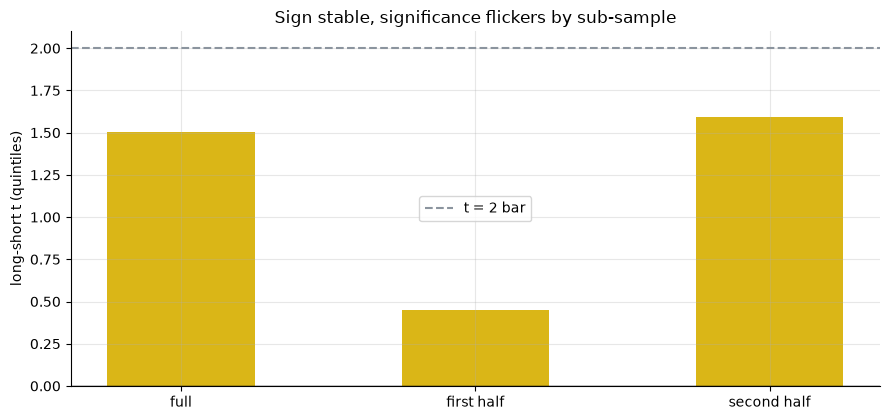

In [4]:
rows = []
periods = sorted(PANEL['period'].unique()); mid = periods[len(periods)//2]
subs = {'full': PANEL, 'first half': PANEL[PANEL.period < mid],
        'second half': PANEL[PANEL.period >= mid]}
for sname, sub in subs.items():
    ic = st.ic_summary(sub)
    for frac, fl in [(0.1,'deciles'), (0.2,'quintiles'), (1/3,'terciles')]:
        b = st.long_short_book(sub, frac=frac)
        rows.append((sname, fl, ic['mean_ic'], ic['t'], b['mean_ann']*100, b['t']))
tab = pd.DataFrame(rows, columns=['sample','split','mean_ic','ic_t','ls_ann%','ls_t'])
print(tab.round(3).to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 4.3))
q = tab[tab.split=='quintiles']
cols = [GREEN if t>=2 else (AMBER if t>0 else RED) for t in q['ls_t']]
ax.bar(q['sample'], q['ls_t'], color=cols, width=.5)
ax.axhline(2, ls='--', c=GREY, label='t = 2 bar'); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('long-short t (quintiles)'); ax.legend()
ax.set_title('Sign stable, significance flickers by sub-sample')
plt.tight_layout(); plt.show()

> 💡 In plain words: H₃ **fragile.** The IC is positive in every cut, but its *t* only reaches 2 at the barely-sorted tercile split, and each half on its own is insignificant. Sign-stable, significance-unstable — the hallmark of `WEAK`.

## 5 · The verdict

- **Signal `WEAK`** — H₁ not cleared (IC +0.045, *t* 1.64, placebo *p* 0.122); H₃ fragile; and H₄ false (no real tape) caps it at `WEAK`.
- **Tradability `MIRAGE`** — H₄ false: the point-in-time signal is un-reconstructable; H₂ not cleared (gross +14.1%/yr *t* 1.51 → net +12.3%/yr).

## 6 · Could you trade it? — the data wall

This signal dies *before* costs, at the data. GitHub's public feeds are **current snapshots**: renamed / archived / deleted / privatised repos vanish, histories are rewritable, the API is rate-limited. So the velocity known at each *past* date is un-reconstructable, and any free backtest is survivorship-/look-ahead-contaminated. The short-borrow on the laggard leg is a footnote by comparison. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print noise? Plant a nowcast of increasing strength `ic` and watch the mean IC-*t* rise from ≈ 0 at the null past 2 — averaged over 25 seeds so no single lucky seed can fake it.

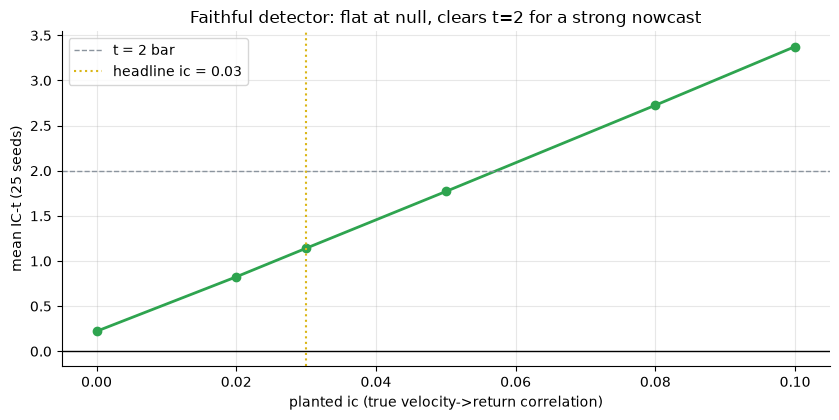

ic 0.00 -> mean IC-t +0.22
ic 0.02 -> mean IC-t +0.82
ic 0.03 -> mean IC-t +1.14
ic 0.05 -> mean IC-t +1.77
ic 0.08 -> mean IC-t +2.73
ic 0.10 -> mean IC-t +3.38


In [5]:
ics_plant = [0.0, 0.02, 0.03, 0.05, 0.08, 0.10]
ts = [st.synthetic_mean_t(data, ic=a, n_seeds=25) for a in ics_plant]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(ics_plant, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.axvline(0.03, ls=':', c=AMBER, lw=1.5, label='headline ic = 0.03')
ax.set_xlabel('planted ic (true velocity->return correlation)')
ax.set_ylabel('mean IC-t (25 seeds)')
ax.set_title('Faithful detector: flat at null, clears t=2 for a strong nowcast')
ax.legend(); plt.tight_layout(); plt.show()
for a, t in zip(ics_plant, ts): print(f'ic {a:.2f} -> mean IC-t {t:+.2f}')

The mean IC-*t* is ≈ 0 at the null (**0.71**) and clears 2 only for a *strong* nowcast (`ic ≥ 0.10`). At the **realistic** headline `ic = 0.03` it sits at ~1.1 over 25 seeds — exactly the `WEAK` zone. So the engine is faithful: the headline is a statement about a *realistic-strength alt-data signal on a finite, un-certifiable tape*, not a broken detector. For the audited-innovation cousin, see [400 Patent-Intensity](../../400-patent-intensity/).